# REED-VAE Table 1, replicated with the SPNN codec

Almog, Shamir & Fried, *REED-VAE: RE-Encode Decode Training for Iterative Image Editing with
Diffusion Models*, Computer Graphics Forum **44**(2), e70020, 2025.

Table 1 of that paper measures how well five diffusion editing models survive **iterative**
editing. The same image is edited 25 times in a row, alternating between a pair of inverse
edits, and quality is measured after 5, 15 and 25 operations. Each base row is the editing
model with its stock vanilla VAE; each `+ REED` row is the *identical* run with only the VAE
swapped for REED-VAE.

This notebook runs that experiment unchanged, with one substitution:

| paper | here |
| --- | --- |
| Vanilla-VAE (Stable Diffusion KL-f8, 4-channel) | **SD 1.5 VAE** &mdash; `stable-diffusion-v1-5/stable-diffusion-v1-5`, subfolder `vae` |
| REED-VAE | **SPNN codec** &mdash; `spnn_model.SPNNAutoencoder512` + `ckpt_last.pt` |

> **Why SD1.5 and not SD2.1.** Every `stabilityai/*` repository 404s from this machine, with or
> without the cached HF token, so SD2's VAE cannot be fetched here at all. SD1.5's VAE is the
> better baseline anyway: it is the stock VAE of three of the five editing models, and it is the
> exact teacher `ckpt_last.pt` was distilled against (`z_t = 0.18215 * vae.encode(x).mean`), so
> the base row and the SPNN row share a latent space by construction rather than by argument.
> `VANILLA_VAE_ID` is one line in `CONFIG` if SD2 access comes back.

So the `IP2P` row is "InstructPix2Pix driven through the stock SD1.5 codec", and each `+ SPNN`
row beneath it is that same run with an SPNN checkpoint in the VAE's place; likewise for
MagicBrush, DiffEdit, Paint-by-Example and SD Inpainting. **Every number in the final table is produced by this
notebook from its own runs.** The paper's published numbers appear exactly once, in a
clearly-labelled reference cell at the very end, and only for context.

> **Do not run this top to bottom in an interactive kernel.** The full grid is
> 5 editing models x 2 codecs x 179 images x 25 diffusion edits ~= 45k pipeline calls,
> on the order of 30-60 A100-hours. Section 11 writes a SLURM array script that runs one
> `(model, codec)` arm per job; every arm resumes from whatever it already wrote.

## 1. The protocol, as the paper specifies it

**Dataset.** ImagenHub, adapted to iterative editing. The Table 1 caption: *"Metrics are
computed based on experiments done on the ImagenHub dataset, consisting of 179 images."*
The copy in `REED-VAE-data/` is that 179-sample split &mdash; `imagenhub_edit_instructions.csv`
(179 rows: `instruction`, `reverse_instruction`, `source_global_caption`,
`target_global_caption`, `target_local_caption`) plus
`images/{img_id}_t{turn}_{src,tgt,mask}.png` at 512x512.

**Inverse edit pairs** (Section 5): *"we perform a pair of 'inverse edit operations'
{e1, e2} on each test image, iterating back and forth through these operations for multiple
cycles. For example, e1 might be some edit operation to 'change the car into a bus', then e2
will be to 'change the bus into a car'."*

Per model:

* **IP2P / MagicBrush** (Sec. 5.2) take `{x_s, I_s}`. The paper *"manually add[s] reverse
  prompts to perform each given edit in the opposite direction"* &mdash; that is the
  `reverse_instruction` column. Odd steps apply `instruction`, even steps `reverse_instruction`.
* **DiffEdit** (Sec. 5.2) takes `{x_s, C_s, C_t}`, made iterative *"by repeatedly editing x_s
  in alternating directions of either C_t or C_s"*. Odd steps go C_s -> C_t, even steps C_t -> C_s.
* **PbE** (Sec. 5.4) takes `{x_s, C_t, m}` plus a reference image. The paper applies the initial
  mask to `x_s`, takes a tight bounding box around it, and builds `x2r`, *"a new reference image
  containing the original object from x_s that we replaced in the previous edit operation"*;
  then *"at each iterative step we provide {x_s, m}, and one of either x1r or x2r"*.
* **SD Inpainting** (Sec. 5.3) takes `{x_s, C_t^local, m}`: *"To simplify the evaluation, we
  repeat the same inpainting task across all iterations, inpainting the same object C_t^local
  into the masked region at each step."*

**Metrics.** MSE, LPIPS, SSIM, FID, PSNR, each reported at 5 / 15 / 25 iterations. Table 1
caption: *"MSE, PSNR, and LPIPS are computed with each image sample normalized to the [0,1]
range prior to evaluation... Other metrics are computed as per their standard definitions."*

### Two things the paper leaves open

Both are `CONFIG` switches, so they can be changed without touching any other cell.

1. **What the metrics are measured against.** The paper never names the reference image. With
   alternating inverse edits the *intended* content after an odd number of steps is the target
   state, so `REFERENCE = "alternating"` scores against `x_t` at 5/15/25 (and would use `x_s` at
   even counts). SD Inpainting repeats one edit, so its reference is `x_t` at every count. FID is
   computed between the 179 outputs at an iteration and the 179 reference images.
2. **Sampler settings.** Not stated. We use each pipeline's documented defaults, collected in
   `EDIT_KWARGS`. The vanilla and SPNN arms are seeded identically per `(image, step)`, so the
   two rows of a block are a *paired* comparison rather than two independent draws.

### One deviation forced by the data

Paint-by-Example's `x1r` in the paper is ImagenHub's own subject reference image, which is not
part of the 179-sample mask-guided split shipped here. We build it the same way the paper builds
`x2r`: crop the mask's tight bounding box, from `x_t` for `x1r` and from `x_s` for `x2r`. The
alternating structure the paper describes is preserved exactly; only the provenance of `x1r`
differs. This is flagged again in the notes at the end.

### Why one codec can drive all five models

All five editing models here are SD1.5-family and share the same KL-f8, 4-channel latent space
with `scaling_factor = 0.18215`. That is exactly what lets REED-VAE (Sec. 4: *"as our REED-VAE is
based on the architecture of the vanilla VAE used in Stable Diffusion, it can be easily swapped
into the vast majority of models"*) be trained once and dropped into all of them, and the same
holds for `ckpt_last.pt`. Because the vanilla codec here *is* the distillation teacher, Section 4b's
latent-agreement check reads directly as distillation quality: any residual gap is SPNN's own
approximation error and nothing else.

## 2. Configuration

In [26]:
# ============================== CONFIG ==============================
import os
from pathlib import Path

import torch

PROJECT  = Path(os.environ.get("REED_PROJECT", "/home/ron.libman/churches-reboot"))
CSV_PATH = PROJECT / "imagenhub_edit_instructions (2).csv"          # the paper's revised 179-row split
IMG_DIR  = Path("/rg/shocher_prj/ron.libman/reed_table1/data")      # rebuilt by reed_build_data.py

# Deliberately NOT `work/`: that symlinks to /rg/shocher_prj, whose 4 TB project quota is
# exhausted -- `df /rg` reports the healthy 200 TB volume, `df /rg/shocher_prj` reports 100%
# with 0 bytes free, so writes there die with ENOSPC while mkdir/touch may still succeed.
# Budget: 5370 PNGs at ~358 KB = ~1.9 GB for the grid, plus ~0.75 GB for the Section 10 appendix.
BASE_OUT = Path(os.environ.get("REED_OUT", "/rg/shocher_prj/ron.libman/reed_table1/out"))
OUT_ROOT = BASE_OUT                  # a sample filter appends a suffix; see below
RUN_DIR  = OUT_ROOT / "rollouts"     # rollouts/<editor>/<codec>/iter<N>/<sid>.png
REF_DIR  = OUT_ROOT / "refs"         # refs/target/<sid>.png, refs/source/<sid>.png
TAB_DIR  = OUT_ROOT / "tables"

# ---------------- codecs ----------------
# The whole stabilityai org 404s from this machine (anonymously and with the cached token), so
# SD2's VAE is not obtainable here. SD1.5's is also the checkpoint SPNN was distilled from, and
# is the stock VAE of IP2P / MagicBrush / PbE. Swap this line if SD2 access returns.
VANILLA_VAE_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"   # subfolder="vae"
# One Table 1 row per entry, beneath each editor's vanilla base row. Both are SPNN-512 with
# the same architecture (householder, scale_bound 1.0) and the same 0.18215 latent scale,
# distilled from the same SD1.5 VAE, so both drop into the same slot.
#
# NOTE: spnn_laion points inside a live training run (runs/ -> runs_local/spnn512_laion20k).
# ckpt_best.pt is rewritten every time validation improves, so a table built from it is only
# reproducible against the copy that existed at the time. Snapshot it first for a fixed result:
#     cp runs/spnn512_laion20k/ckpt_best.pt ckpt_laion_ep29.pt
SPNN_CKPTS = {   # the phase-2 codec: Re-LAION+COCO, LPIPS from epoch 4, best.pt by val cycle LPIPS
    "spnn": Path("/rg/shocher_prj/ron.libman/laion1m/runs/spnn512/best.pt"),
}
SPNN_CKPT      = SPNN_CKPTS["spnn"]     # the single-file default, for messages naming just one
SPNN_WEIGHTS   = "ema"        # "ema" (the EMA shadow) or "model" (raw weights)
SPNN_SCALE     = 0.18215      # ckpt_last.pt was distilled onto 0.18215 * vae.encode(x).mean
SPNN_FP32      = True         # keep the codec in fp32 even when the pipeline runs fp16

CODECS = tuple(SPNN_CKPTS) + ("hybrid", "vanilla")    # SPNN first: it is ~5x faster, so its arms land first

# ---------------- editing models ----------------
EDITORS = ("IP2P", "MagicBrush", "DiffEdit", "PbE", "SDInpaint")

# All five are already complete in ~/.cache/huggingface/hub, so the grid runs fully offline.
MODEL_IDS = {
    "IP2P":       "timbrooks/instruct-pix2pix",
    "MagicBrush": "vinesmsuic/magicbrush-jul7",                    # ImagenHub's MagicBrush ckpt
    "DiffEdit":   "stable-diffusion-v1-5/stable-diffusion-v1-5",   # any SD txt2img + a DDIM pair
    "PbE":        "Fantasy-Studio/Paint-by-Example",
    "SDInpaint":  "runwayml/stable-diffusion-inpainting",          # the 9-channel SD1.5 inpainter
}

# Each pipeline's documented defaults; the paper does not state sampler settings.
EDIT_KWARGS = {
    "IP2P":       dict(num_inference_steps=100, guidance_scale=7.5, image_guidance_scale=1.5),
    "MagicBrush": dict(num_inference_steps=100, guidance_scale=7.5, image_guidance_scale=1.5),
    "DiffEdit":   dict(num_inference_steps=50, guidance_scale=7.5, inpaint_strength=0.8,
                       mask_encode_strength=0.5, num_maps_per_mask=10),
    "PbE":        dict(num_inference_steps=50, guidance_scale=5.0),
    "SDInpaint":  dict(num_inference_steps=50, guidance_scale=7.5),
}

# ---------------- protocol ----------------
N_ITERS    = 25
SAVE_AT    = (5, 15, 25)      # the three columns of Table 1
RESOLUTION = 512
REFERENCE  = "alternating"    # "alternating" | "target" | "source"
KEEP_UINT8 = True             # round-trip 8-bit pixels between steps, as a saved file would
SAVE_ALL_EDITS = os.environ.get("REED_SAVE_ALL", "1") == "1"   # every iteration, not just 5/15/25:
                              # the three scored ones stay lossless PNG (metrics + resume read them),
                              # the other 22 go to JPEG q95 for viewing (~6 GB for the whole grid)
SEED       = 0

METRICS = ("MSE", "LPIPS", "SSIM", "FID", "PSNR")   # Table 1 column order

# ---------------- runtime ----------------
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
PIPE_DTYPE    = torch.float16 if DEVICE == "cuda" else torch.float32
LPIPS_NET     = "alex"
HF_LOCAL_ONLY = os.environ.get("HF_HUB_OFFLINE", "0") == "1"
LIMIT         = None          # int -> use only the first N samples (pilot runs)

# Restrict the run to named samples. An entry is either a full sid ("106772_t1", one row) or a
# bare img_id ("106772", every turn of that image -- 106772 has two, _t1 and _t2). Empty list
# = the whole set. Takes precedence over SUBSET_N and LIMIT.
ONLY_IDS      = [x for x in os.environ.get("REED_IDS", "").split(",") if x.strip()]

# Pilot runs: a random subset, drawn from a fixed seed so every arm -- and every SLURM task --
# sees the SAME images. A per-arm draw would silently unpair the vanilla/SPNN comparison.
SUBSET_N      = int(os.environ.get("REED_SUBSET", "0")) or None
SUBSET_SEED   = int(os.environ.get("REED_SUBSET_SEED", "0"))
ARRAY_CONCURRENCY = int(os.environ.get("REED_CONCURRENCY", "4"))   # GPUs to use at once

# One SLURM task = one (editor, codec) arm. Unset in an interactive kernel -> run everything.
ONLY_EDITOR = os.environ.get("ARM_EDITOR") or None
ONLY_CODEC  = os.environ.get("ARM_CODEC") or None

# Keep a filtered run's outputs out of the full run's tree.
if ONLY_IDS:
    OUT_ROOT = BASE_OUT.parent / f"{BASE_OUT.name}_ids{'-'.join(ONLY_IDS)}"
elif SUBSET_N:
    OUT_ROOT = BASE_OUT.parent / f"{BASE_OUT.name}_n{SUBSET_N}s{SUBSET_SEED}"
if OUT_ROOT != BASE_OUT:
    RUN_DIR, REF_DIR, TAB_DIR = OUT_ROOT / "rollouts", OUT_ROOT / "refs", OUT_ROOT / "tables"

if os.environ.get("REED_SMOKE") == "1":      # 4 images x 5 iterations, for a plumbing check
    LIMIT, N_ITERS, SAVE_AT = 4, 5, (5,)
    for k in EDIT_KWARGS:
        EDIT_KWARGS[k]["num_inference_steps"] = 10
    OUT_ROOT = OUT_ROOT.parent / (OUT_ROOT.name + "_smoke")
    RUN_DIR, REF_DIR, TAB_DIR = OUT_ROOT / "rollouts", OUT_ROOT / "refs", OUT_ROOT / "tables"

for d in (RUN_DIR, REF_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

ARMS = [(e, c) for e in EDITORS for c in CODECS
        if (ONLY_EDITOR in (None, e) and ONLY_CODEC in (None, c))]

print(f"device={DEVICE} dtype={PIPE_DTYPE}  out={OUT_ROOT}")
print(f"{len(ARMS)} arm(s) selected: {ARMS}")

device=cuda dtype=torch.float16  out=/home/ron.libman/iclr0409/reed_table1_spnn_out_ids106772
15 arm(s) selected: [('IP2P', 'vanilla'), ('IP2P', 'spnn'), ('IP2P', 'spnn_laion'), ('MagicBrush', 'vanilla'), ('MagicBrush', 'spnn'), ('MagicBrush', 'spnn_laion'), ('DiffEdit', 'vanilla'), ('DiffEdit', 'spnn'), ('DiffEdit', 'spnn_laion'), ('PbE', 'vanilla'), ('PbE', 'spnn'), ('PbE', 'spnn_laion'), ('SDInpaint', 'vanilla'), ('SDInpaint', 'spnn'), ('SDInpaint', 'spnn_laion')]


In [27]:
import hashlib
import json
import math
import random
import shutil
import sys
import time
import warnings

import numpy as np
import pandas as pd
from PIL import Image

warnings.filterwarnings("ignore", category=UserWarning)

import diffusers
print("torch", torch.__version__, "| diffusers", diffusers.__version__)


def gpu_report():
    """Free VRAM, not just the card name.

    The GPU inside an interactive SLURM allocation is shared with every other kernel that
    allocation has ever started, so a card can read as "A100 40GB" and have 13 MiB free.
    Check this before starting an arm, not six hours in.
    """
    if DEVICE != "cuda":
        print("cpu")
        return
    free, total = torch.cuda.mem_get_info()
    print(f"gpu: {torch.cuda.get_device_name(0)}  {free / 2**30:.1f} / {total / 2**30:.1f} GiB free")
    if free < 12 * 2**30:
        print("  WARNING: under 12 GiB free -- another process (most likely a stale Jupyter\n"
              "  kernel in this same allocation) is holding the card. `nvidia-smi` on the node,\n"
              "  or Jupyter's Running tab, will show which. An arm needs roughly 8-14 GiB.")


gpu_report()

torch 2.0.1+cu118 | diffusers 0.24.0
gpu: NVIDIA A100-SXM4-40GB  37.7 / 39.6 GiB free


### 2b. Prefetch (already satisfied on this machine)

Everything this notebook loads is present in `~/.cache`: all five pipelines with their weights,
the SD1.5 VAE, AlexNet for LPIPS and `pt_inception-2015-12-05` for FID. So `HF_HUB_OFFLINE=1` in
the SLURM script is safe as it stands. Run this cell from a node with network access only if you
change a `MODEL_IDS` entry or move the cache.

In [28]:
def prefetch():
    from diffusers import (AutoencoderKL, PaintByExamplePipeline,
                           StableDiffusionDiffEditPipeline,
                           StableDiffusionInpaintPipeline,
                           StableDiffusionInstructPix2PixPipeline)
    AutoencoderKL.from_pretrained(VANILLA_VAE_ID, subfolder="vae")
    for name, cls in [("IP2P", StableDiffusionInstructPix2PixPipeline),
                      ("MagicBrush", StableDiffusionInstructPix2PixPipeline),
                      ("DiffEdit", StableDiffusionDiffEditPipeline),
                      ("PbE", PaintByExamplePipeline),
                      ("SDInpaint", StableDiffusionInpaintPipeline)]:
        print("fetching", name, MODEL_IDS[name], flush=True)
        cls.from_pretrained(MODEL_IDS[name], safety_checker=None)
    import lpips
    lpips.LPIPS(net=LPIPS_NET)
    from pytorch_fid.inception import InceptionV3
    InceptionV3([InceptionV3.BLOCK_INDEX_BY_DIM[2048]])
    print("prefetch done")

# prefetch()      # <- uncomment and run once, on a node with network access

## 3. The 179-image evaluation set

In [29]:
def load_rgb(path, size=RESOLUTION):
    """PNG -> float32 HWC in [0, 1]."""
    im = Image.open(path).convert("RGB")
    if im.size != (size, size):
        im = im.resize((size, size), Image.LANCZOS)
    return np.asarray(im, dtype=np.float32) / 255.0


def load_mask(path, size=RESOLUTION):
    """PNG -> float32 HW in {0, 1}; 1 = region to edit (diffusers' convention)."""
    im = Image.open(path).convert("L")
    if im.size != (size, size):
        im = im.resize((size, size), Image.NEAREST)
    return (np.asarray(im, dtype=np.float32) / 255.0 > 0.5).astype(np.float32)


def to_pil(arr):
    return Image.fromarray((np.clip(arr, 0.0, 1.0) * 255.0).round().astype(np.uint8))


def quantize(arr):
    """8-bit round-trip without going through PIL."""
    return (np.clip(arr, 0.0, 1.0) * 255.0).round() / 255.0


def mse(a, b):
    """Mean squared error on [0,1]-normalised images, per the Table 1 caption."""
    return float(np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2))


def psnr(a, b, eps=1e-12):
    return float(10.0 * np.log10(1.0 / max(mse(a, b), eps)))


def mask_bbox(mask, pad=8):
    ys, xs = np.nonzero(mask)
    if len(ys) == 0:                       # empty mask -> whole image
        return 0, 0, mask.shape[1], mask.shape[0]
    y0, y1 = max(int(ys.min()) - pad, 0), min(int(ys.max()) + 1 + pad, mask.shape[0])
    x0, x1 = max(int(xs.min()) - pad, 0), min(int(xs.max()) + 1 + pad, mask.shape[1])
    return x0, y0, x1, y1

In [30]:
df = pd.read_csv(CSV_PATH)
print(f"{len(df)} rows in {CSV_PATH.name}; columns: {list(df.columns)[1:]}")

SAMPLES = []
for _, r in df.iterrows():
    sid = f"{r['img_id']}_t{r['turn_index']}"
    paths = {k: IMG_DIR / f"{sid}_{k}.png" for k in ("src", "tgt", "mask")}
    missing = [str(p) for p in paths.values() if not p.exists()]
    if missing:
        raise FileNotFoundError(missing[0])
    SAMPLES.append(dict(
        sid=sid,
        src=paths["src"], tgt=paths["tgt"], mask=paths["mask"],
        instruction=str(r["instruction"]),
        reverse_instruction=str(r["reverse_instruction"]),
        source_caption=str(r["source_global_caption"]),
        target_caption=str(r["target_global_caption"]),
        local_caption=str(r["target_local_caption"]),
    ))

if ONLY_IDS:
    want = set(ONLY_IDS)
    SAMPLES = [s for s in SAMPLES
               if s["sid"] in want or s["sid"].rsplit("_t", 1)[0] in want]
    missing = want - {s["sid"] for s in SAMPLES} - {s["sid"].rsplit("_t", 1)[0] for s in SAMPLES}
    if missing:
        raise SystemExit(f"REED_IDS/ONLY_IDS matched nothing for: {sorted(missing)}")
    print(f"restricted to {ONLY_IDS} -> {[s['sid'] for s in SAMPLES]}")
elif SUBSET_N:
    pick = sorted(random.Random(SUBSET_SEED).sample(range(len(SAMPLES)), SUBSET_N))
    SAMPLES = [SAMPLES[i] for i in pick]
    print(f"random subset seed={SUBSET_SEED}: rows {pick}")
elif LIMIT is not None:
    SAMPLES = SAMPLES[:LIMIT]
print(f"{len(SAMPLES)} samples "
      f"({'the full 179-image set of the paper' if len(SAMPLES) == 179 else 'SUBSET'})")
SAMPLES[0]

179 rows in imagenhub_edit_instructions.csv; columns: ['img_id', 'turn_index', 'instruction', 'reverse_instruction', 'source_global_caption', 'target_global_caption', 'target_local_caption']
restricted to ['106772'] -> ['106772_t1', '106772_t2']
2 samples (SUBSET)


{'sid': '106772_t1',
 'src': PosixPath('/home/ron.libman/iclr0409/REED-VAE-data/images/106772_t1_src.png'),
 'tgt': PosixPath('/home/ron.libman/iclr0409/REED-VAE-data/images/106772_t1_tgt.png'),
 'mask': PosixPath('/home/ron.libman/iclr0409/REED-VAE-data/images/106772_t1_mask.png'),
 'instruction': 'What if the child was holding a bottle of pepper?',
 'reverse_instruction': 'What if the child was holding a bottle of salt?',
 'source_caption': 'A small child cooking some macaroni and cheese',
 'target_caption': 'A small child cooking macaroni and cheese while holding a bottle of pepper',
 'local_caption': 'child holding bottle of pepper'}

In [31]:
def sample_assets(s):
    """Everything an editor may need for one sample, loaded once per rollout.

    x1r / x2r follow Sec. 5.4: the mask's tight bounding box, cropped out of the target
    image (the object PbE should paint in) and out of the source image (the object it
    replaced), so the two references are exact inverses of each other.
    """
    src, tgt = load_rgb(s["src"]), load_rgb(s["tgt"])
    mask = load_mask(s["mask"])
    box = mask_bbox(mask)
    return dict(
        src=src, tgt=tgt, mask=mask,
        mask_pil=Image.fromarray((mask * 255).astype(np.uint8)),
        ref_target=to_pil(tgt).crop(box),   # x1r
        ref_source=to_pil(src).crop(box),   # x2r
    )


def reference_path(s, editor, n_iter):
    """Which ground-truth image iteration `n_iter` of `editor` should be scored against."""
    if editor == "SDInpaint" or REFERENCE == "target":
        return s["tgt"]                       # one edit, repeated -> always the target state
    if REFERENCE == "source":
        return s["src"]
    return s["tgt"] if n_iter % 2 == 1 else s["src"]     # "alternating"


# Materialise the two reference folders once; FID needs directories of images.
for kind in ("target", "source"):
    d = REF_DIR / kind
    d.mkdir(parents=True, exist_ok=True)
    for s in SAMPLES:
        out = d / f"{s['sid']}.png"
        if not out.exists():
            to_pil(load_rgb(s["tgt" if kind == "target" else "src"])).save(out)
print("reference folders:", {k: len(list((REF_DIR / k).glob('*.png'))) for k in ('target', 'source')})

reference folders: {'target': 2, 'source': 2}


## 4. The two codecs

Both are exposed to the pipelines as an `AutoencoderKL`, so `pipe.vae = codec` is the entire
swap &mdash; exactly the drop-in the paper describes for REED-VAE.

`SPNNAutoencoderKL` subclasses `AutoencoderKL` (so `.config`, `.dtype`, `.to()` and the
`AutoencoderKLOutput` / `DecoderOutput` contracts are all inherited verbatim), throws away the
SD conv stacks, and routes `encode`/`decode` through the SPNN network.

**The one thing that has to be right is the scale.** `ckpt_last.pt` was distilled against
`z_t = 0.18215 * vae.encode(x).latent_dist.mean`, so `spnn.encode(x)` already carries the
`0.18215` factor. Diffusers pipelines expect `vae.encode(...).latent_dist` to be the *unscaled*
latent and apply `config.scaling_factor` themselves &mdash; and IP2P deliberately does *not*
scale its image-conditioning latents. Dividing by `SPNN_SCALE` on the way out of `encode` and
multiplying it back on the way into `decode` makes the adapter correct at every call site,
scaled or not.

Since the codec is deterministic, `latent_dist` is a `DiagonalGaussianDistribution` with
`logvar = -30` (std ~ 3e-7), so `.sample()` and `.mode()` agree to well under fp16 resolution.

In [32]:
import inspect

import torch.nn as nn
from diffusers import AutoencoderKL
try:                                    # diffusers <= 0.25 (what this notebook was written against)
    from diffusers.models.autoencoder_kl import AutoencoderKLOutput
    from diffusers.models.vae import DecoderOutput, DiagonalGaussianDistribution
except ModuleNotFoundError:             # diffusers >= 0.26 moved both modules
    from diffusers.models.modeling_outputs import AutoencoderKLOutput
    from diffusers.models.autoencoders.vae import DecoderOutput, DiagonalGaussianDistribution

sys.path.insert(0, str(PROJECT))
from spnn_model_opt import SPNNAutoencoder512Opt


def load_spnn(ckpt_path=SPNN_CKPT, weights=SPNN_WEIGHTS):
    """train_spnn512.py checkpoint layout: model / ema / state / args.

    The architecture is SPNNAutoencoder512Opt's defaults (householder, hidden 96, r_hidden 128,
    scale_bound 1.0), which is what the run trained, so load_state_dict is strict: a mismatch
    raises here rather than silently decoding garbage. `ema` holds only floating-point tensors,
    so it is overlaid on the model state rather than loaded on its own.
    """
    ck = torch.load(str(ckpt_path), map_location="cpu", weights_only=False)
    net = SPNNAutoencoder512Opt()
    net.load_state_dict(ck["model"])
    if weights == "ema":
        sd = net.state_dict()
        sd.update({k: v.to(sd[k].dtype) for k, v in ck["ema"].items()})
        net.load_state_dict(sd)
    st = ck.get("state", {})
    print(f"SPNN['{weights}'] step={st.get('step')} epoch={round(st.get('step', 0) / 5426, 2)} "
          f"val cycle {st.get('best_metric', 'psnr')}={st.get('best')}")
    del ck
    return net.eval().requires_grad_(False)


class SPNNAutoencoderKL(AutoencoderKL):
    """The SPNN codec wearing an AutoencoderKL's interface."""

    def __init__(self, spnn, latent_scale=SPNN_SCALE, **vae_config):
        super().__init__(**vae_config)
        # The SD encoder/decoder are never called; drop them rather than carry ~330 MB of
        # dead weights into VRAM. Keeping them as Identity keeps .to()/.dtype well-defined.
        self.encoder = nn.Identity()
        self.decoder = nn.Identity()
        self.quant_conv = nn.Identity()
        self.post_quant_conv = nn.Identity()
        self.spnn = spnn
        self.latent_scale = float(latent_scale)
        self.use_slicing = False
        self.use_tiling = False

    @classmethod
    def from_vanilla(cls, spnn, vanilla_vae, latent_scale=SPNN_SCALE):
        allowed = set(inspect.signature(AutoencoderKL.__init__).parameters)
        cfg = {k: v for k, v in dict(vanilla_vae.config).items() if k in allowed}
        return cls(spnn, latent_scale=latent_scale, **cfg)

    @property
    def codec_dtype(self):
        """What the SPNN weights are in -- fp32 when SPNN_FP32, regardless of the pipeline."""
        return next(self.spnn.parameters()).dtype

    def to(self, *args, **kwargs):
        out = super().to(*args, **kwargs)
        dt = kwargs.get("dtype") or next((a for a in args if isinstance(a, torch.dtype)), None)
        if dt is not None:
            out._pipe_dtype = dt
        return out

    @property
    def dtype(self):
        """The dtype the surrounding *pipeline* runs in, which is not the codec's.

        A real AutoencoderKL answers this from its conv stacks; ours are nn.Identity, so the
        only parameters left are SPNN's, and SPNN_FP32 makes those fp32. DiffEdit is the one
        pipeline that reads `self.vae.dtype` directly -- to build the latents it feeds the UNet
        (pipeline_stable_diffusion_diffedit.py:1042) -- so reporting fp32 there hands an fp16
        UNet fp32 latents and it dies in the timestep embedding. Report the pipeline dtype.
        """
        dt = self.__dict__.get("_pipe_dtype")
        return dt if dt is not None else next(self.parameters()).dtype

    @staticmethod
    def _posterior(z32, dtype):
        """A DiagonalGaussianDistribution around z with (numerically) zero variance.

        Built in fp32 because DiagonalGaussianDistribution.__init__ calls torch.clamp on
        the parameters, and clamp has no half kernel on CPU; the fields are cast afterwards
        so .mode()/.sample() still hand the pipeline its own dtype.
        """
        logvar = torch.full_like(z32, -30.0)        # std ~ 3e-7 -> sample() == mode()
        post = DiagonalGaussianDistribution(torch.cat([z32, logvar], dim=1))
        if dtype != torch.float32:
            for f in ("parameters", "mean", "logvar", "std", "var"):
                setattr(post, f, getattr(post, f).to(dtype))
        return post

    def encode(self, x, return_dict=True):
        z = self.spnn.encode(x.to(self.codec_dtype)) / self.latent_scale
        posterior = self._posterior(z.float(), x.dtype)
        return (posterior,) if not return_dict else AutoencoderKLOutput(latent_dist=posterior)

    def _decode(self, z, return_dict=True):
        out_dtype = z.dtype
        x = self.spnn.decode(z.to(self.codec_dtype) * self.latent_scale).to(out_dtype)
        return (x,) if not return_dict else DecoderOutput(sample=x)

    def decode(self, z, return_dict=True, generator=None):
        x = self._decode(z, return_dict=True).sample
        return (x,) if not return_dict else DecoderOutput(sample=x)


class HybridAutoencoderKL(AutoencoderKL):
    """SD-1.5 VAE encoder (unchanged, frozen) + SPNN decoder -- REED's own configuration.

    Loaded with from_pretrained so the real encoder weights are present; only the decode path
    is overridden. SPNN was distilled onto 0.18215 * vae.encode(x).mean, and diffusers hands
    `decode` the UNSCALED latent, so the same `* latent_scale` as SPNNAutoencoderKL applies.
    Note this gives up exact idempotency: E_vae(D_spnn(z)) != z.
    """

    def attach(self, spnn, latent_scale=SPNN_SCALE):
        self.spnn = spnn
        self.latent_scale = float(latent_scale)
        return self

    def _decode(self, z, return_dict=True):
        out_dtype = z.dtype
        cd = next(self.spnn.parameters()).dtype
        x = self.spnn.decode(z.to(cd) * self.latent_scale).to(out_dtype)
        return (x,) if not return_dict else DecoderOutput(sample=x)

    def decode(self, z, return_dict=True, generator=None):
        x = self._decode(z, return_dict=True).sample
        return (x,) if not return_dict else DecoderOutput(sample=x)


def build_codec(name, device=DEVICE, dtype=PIPE_DTYPE):
    vanilla = AutoencoderKL.from_pretrained(VANILLA_VAE_ID, subfolder="vae",
                                            local_files_only=HF_LOCAL_ONLY)
    if name == "vanilla":
        vae = vanilla
    elif name == "hybrid":
        vae = HybridAutoencoderKL.from_pretrained(VANILLA_VAE_ID, subfolder="vae",
                                                  local_files_only=HF_LOCAL_ONLY)
        vae = vae.attach(load_spnn(SPNN_CKPTS.get("spnn", SPNN_CKPT)))
    elif name in SPNN_CKPTS:
        # `vanilla` is used only as a config donor here; its weights are dropped.
        vae = SPNNAutoencoderKL.from_vanilla(load_spnn(SPNN_CKPTS[name]), vanilla)
    else:
        raise ValueError(f"unknown codec {name!r}: expected 'vanilla' or one of {list(SPNN_CKPTS)}")
    vae = vae.to(device=device, dtype=dtype).eval().requires_grad_(False)
    if name != "vanilla" and SPNN_FP32:
        vae.spnn.float()        # encode/decode cast around it via `codec_dtype`
    return vae

### 4b. Sanity check &mdash; is the SPNN codec really a drop-in?

Two things must hold before any of the 45k pipeline calls are worth spending:

1. `spnn.encode(x)` has to land on the *same* latent manifold as `0.18215 * vae.encode(x).mean`,
   otherwise the frozen UNets are being fed out-of-distribution latents and the comparison is
   measuring the mismatch, not the codec.
2. A single encode-decode has to be roughly as good as the vanilla VAE's. Sec. 4.3 of the paper
   makes the same point for REED: *"we are satisfied if we match the original model's performance
   after one iteration, as long as we improve it for consecutive iterations."*

This cell also runs the pure encode-decode curve &mdash; the Table 2 setting, no diffusion model
in the loop &mdash; along **two** chains, because for this codec they do not agree:

* **float**: the image stays in float between iterations.
* **uint8**: the image is quantised to 8 bits after every iteration, which is what happens when
  each edit is a file a user saved (`KEEP_UINT8`, the protocol Table 1 runs).

The vanilla VAE barely notices the difference &mdash; its own reconstruction error dominates. The
SPNN codec is exactly stable along the float chain and is not along the uint8 chain, so reporting
one number for it would be reporting half the result. See the notes in Section 12.

In [33]:
def _quantize8(t):
    """8-bit round-trip of a [-1,1] tensor, without leaving the GPU."""
    return ((t.clamp(-1, 1) + 1) * 127.5).round() / 127.5 - 1


@torch.no_grad()
def _roundtrip_curve(vae, x01, marks, uint8):
    """Encode/decode x01 repeatedly, returning {n: PSNR against x01} for n in marks."""
    t = torch.from_numpy(x01).permute(2, 0, 1)[None].to(DEVICE, PIPE_DTYPE) * 2 - 1
    out = {}
    for k in range(1, max(marks) + 1):
        t = vae.decode(vae.encode(t).latent_dist.mode()).sample
        if uint8:
            t = _quantize8(t)
        if k in marks:
            out[k] = psnr((t[0].permute(1, 2, 0).float().cpu().numpy() + 1) / 2, x01)
    return out


@torch.no_grad()
def _roundtrip(vae, x01, n=1, uint8=None):
    """Single-value convenience wrapper; defaults to the protocol Table 1 runs."""
    uint8 = KEEP_UINT8 if uint8 is None else uint8
    t = torch.from_numpy(x01).permute(2, 0, 1)[None].to(DEVICE, PIPE_DTYPE) * 2 - 1
    for _ in range(n):
        t = vae.decode(vae.encode(t).latent_dist.mode()).sample
        if uint8:
            t = _quantize8(t)
    return (t[0].permute(1, 2, 0).float().cpu().numpy() + 1) / 2


@torch.no_grad()
def sanity_check(n_images=8, curve_at=(1, 5, 15, 25)):
    codecs = {c: build_codec(c) for c in CODECS}
    van = codecs["vanilla"]
    xs = [load_rgb(s["src"]) for s in SAMPLES[:n_images]]

    # --- 1. latent agreement: each SPNN ckpt vs the VAE it was distilled from --
    for name, vae in codecs.items():
        if name == "vanilla":
            continue
        lat_err, lat_cos, lat_var = [], [], []
        for x in xs:
            t = torch.from_numpy(x).permute(2, 0, 1)[None].to(DEVICE, PIPE_DTYPE) * 2 - 1
            z_sd = van.encode(t).latent_dist.mode() * van.config.scaling_factor
            z_sp = vae.spnn.encode(t.to(vae.codec_dtype))
            a, b = z_sd.float().flatten(), z_sp.float().flatten()
            lat_err.append(((a - b) ** 2).mean().item())
            lat_cos.append(torch.nn.functional.cosine_similarity(a, b, dim=0).item())
            lat_var.append(a.var().item())
        print(f"{name:11s} latent agreement over {n_images} images: MSE={np.mean(lat_err):.5f}  "
              f"cos={np.mean(lat_cos):.4f}  (teacher latent var={np.mean(lat_var):.3f})")
    print()

    # --- 2. iterative encode/decode, both chains (the Table 2 setting) ---------
    rows = []
    for name, vae in codecs.items():
        for uint8 in (False, True):
            c = _roundtrip_curve(vae, xs[0], set(curve_at), uint8)   # warm shapes
            acc = {k: [v] for k, v in c.items()}
            for x in xs[1:]:
                for k, v in _roundtrip_curve(vae, x, set(curve_at), uint8).items():
                    acc[k].append(v)
            for k, v in acc.items():
                rows.append(dict(codec=name, chain="uint8" if uint8 else "float",
                                 iters=k, PSNR=float(np.mean(v))))

    out = (pd.DataFrame(rows)
             .pivot(index="iters", columns=["codec", "chain"], values="PSNR")
             .round(2))
    del codecs, van
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    print("iterative encode/decode PSNR (higher is better; flat = the codec is a fixed point)")
    return out


# Skipped inside a per-arm SLURM task: it would reload the 1 GB checkpoint and redo the same
# encode/decode sweep in all ten of them. Run it once, interactively.
SANITY = sanity_check() if (ONLY_EDITOR is None and ONLY_CODEC is None) else None
SANITY

/home/ron.libman/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


SPNN['ema'] epoch=27 update=139020 arch={'mix_type': 'householder', 'hidden': 128, 'r_hidden': 256, 'scale_bound': 1.0}
SPNN['ema'] epoch=29 update=2310 arch={'mix_type': 'householder', 'hidden': 128, 'r_hidden': 256, 'scale_bound': 1.0}
spnn        latent agreement over 8 images: MSE=0.02440  cos=0.9797  (teacher latent var=0.610)
spnn_laion  latent agreement over 8 images: MSE=0.02388  cos=0.9801  (teacher latent var=0.610)

iterative encode/decode PSNR (higher is better; flat = the codec is a fixed point)


codec vanilla          spnn        spnn_laion       
chain   float  uint8  float  uint8      float  uint8
iters                                               
1       29.29  29.29  31.11  31.12      31.14  31.14
5       22.51  22.35  31.11  28.09      31.14  28.13
15      13.52  13.76  31.11  22.55      31.13  22.28
25       8.75   9.40  31.10  18.33      31.13  18.80

## 5. The five editing models

One class per row of Table 1. All of them expose the same two-method interface:

```python
ed = IP2PEditor.build()             # load the pipeline once
ed.set_codec(vae)                   # swap in either codec -- this is the whole experiment
img = ed.edit(s, a, img, step, gen) # s: sample, a: sample_assets(s); step is 1-based
```

Odd steps apply `e1`, even steps the inverse edit `e2`.

`edit` takes and returns a float32 `HxWx3` array in `[0, 1]`, i.e. it hands back a *pixel-space*
image every time. That is the point of the benchmark: the paper's setting is a user saving the
result and feeding it to the next tool, so the image crosses the latent boundary once per
operation, and the codec pays for it once per operation.

Safety checkers are disabled everywhere &mdash; a single blanked frame would poison the rest of
a 25-step rollout.

In [34]:
from diffusers import (DDIMInverseScheduler, DDIMScheduler, PaintByExamplePipeline,
                       StableDiffusionDiffEditPipeline, StableDiffusionInpaintPipeline,
                       StableDiffusionInstructPix2PixPipeline)


class Editor:
    name = None

    def __init__(self, pipe):
        self.pipe = pipe

    @classmethod
    def build(cls):
        raise NotImplementedError

    def set_codec(self, vae):
        self.pipe.vae = vae
        return self

    def edit(self, s, a, img, step, generator):
        """s: sample dict, a: sample_assets(s), img: HxWx3 float [0,1], step: 1-based."""
        raise NotImplementedError


def _sd_pipe(cls, model_id):
    pipe = cls.from_pretrained(model_id, torch_dtype=PIPE_DTYPE, safety_checker=None,
                               requires_safety_checker=False, local_files_only=HF_LOCAL_ONLY)
    pipe = pipe.to(DEVICE)
    pipe.safety_checker = None
    pipe.set_progress_bar_config(disable=True)
    return pipe


class IP2PEditor(Editor):
    """Sec. 5.2 -- alternate `instruction` and `reverse_instruction`."""
    name = "IP2P"

    @classmethod
    def build(cls):
        return cls(_sd_pipe(StableDiffusionInstructPix2PixPipeline, MODEL_IDS[cls.name]))

    def edit(self, s, a, img, step, generator):
        prompt = s["instruction"] if step % 2 == 1 else s["reverse_instruction"]
        out = self.pipe(prompt=prompt, image=to_pil(img), generator=generator,
                        output_type="np", **EDIT_KWARGS[self.name])
        return out.images[0]


class MagicBrushEditor(IP2PEditor):
    """Same InstructPix2Pix pipeline, MagicBrush's fine-tuned weights."""
    name = "MagicBrush"


class DiffEditEditor(Editor):
    """Sec. 5.2 -- alternate the edit direction between C_s and C_t.

    Each step is the full DiffEdit recipe: generate_mask(C_source -> C_target),
    DDIM-invert under the source caption, then denoise under the target caption
    inside the mask.
    """
    name = "DiffEdit"

    @classmethod
    def build(cls):
        pipe = StableDiffusionDiffEditPipeline.from_pretrained(
            MODEL_IDS[cls.name], torch_dtype=PIPE_DTYPE, safety_checker=None,
            requires_safety_checker=False, local_files_only=HF_LOCAL_ONLY)
        pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
        pipe.inverse_scheduler = DDIMInverseScheduler.from_config(pipe.scheduler.config)
        pipe = pipe.to(DEVICE)
        pipe.safety_checker = None
        pipe.set_progress_bar_config(disable=True)
        return cls(pipe)

    def edit(self, s, a, img, step, generator):
        c_src, c_tgt = (s["source_caption"], s["target_caption"])
        if step % 2 == 0:
            c_src, c_tgt = c_tgt, c_src
        k = EDIT_KWARGS[self.name]
        pil = to_pil(img)
        mask = self.pipe.generate_mask(
            image=pil, source_prompt=c_src, target_prompt=c_tgt, generator=generator,
            num_maps_per_mask=k["num_maps_per_mask"],
            mask_encode_strength=k["mask_encode_strength"],
            num_inference_steps=k["num_inference_steps"],
            guidance_scale=k["guidance_scale"])
        inv = self.pipe.invert(
            image=pil, prompt=c_src, generator=generator,
            num_inference_steps=k["num_inference_steps"],
            inpaint_strength=k["inpaint_strength"],
            guidance_scale=k["guidance_scale"]).latents
        out = self.pipe(
            prompt=c_tgt, mask_image=mask, image_latents=inv, generator=generator,
            num_inference_steps=k["num_inference_steps"],
            inpaint_strength=k["inpaint_strength"],
            guidance_scale=k["guidance_scale"], output_type="np")
        return out.images[0]


class PbEEditor(Editor):
    """Sec. 5.4 -- alternate the reference between x1r (target object) and x2r (source object)."""
    name = "PbE"

    @classmethod
    def build(cls):
        pipe = PaintByExamplePipeline.from_pretrained(
            MODEL_IDS[cls.name], torch_dtype=PIPE_DTYPE, safety_checker=None,
            local_files_only=HF_LOCAL_ONLY)
        pipe = pipe.to(DEVICE)
        pipe.safety_checker = None
        pipe.set_progress_bar_config(disable=True)
        return cls(pipe)

    def edit(self, s, a, img, step, generator):
        ref = a["ref_target"] if step % 2 == 1 else a["ref_source"]
        out = self.pipe(example_image=ref, image=to_pil(img), mask_image=a["mask_pil"],
                        height=RESOLUTION, width=RESOLUTION, generator=generator,
                        output_type="np", **EDIT_KWARGS[self.name])
        return out.images[0]


class SDInpaintEditor(Editor):
    """Sec. 5.3 -- the same inpainting task, C_t^local into m, repeated every iteration."""
    name = "SDInpaint"

    @classmethod
    def build(cls):
        return cls(_sd_pipe(StableDiffusionInpaintPipeline, MODEL_IDS[cls.name]))

    def edit(self, s, a, img, step, generator):
        out = self.pipe(prompt=s["local_caption"], image=to_pil(img), mask_image=a["mask_pil"],
                        height=RESOLUTION, width=RESOLUTION, generator=generator,
                        output_type="np", **EDIT_KWARGS[self.name])
        return out.images[0]


EDITOR_CLASSES = {c.name: c for c in
                  (IP2PEditor, MagicBrushEditor, DiffEditEditor, PbEEditor, SDInpaintEditor)}

## 6. Iterative rollouts

For each `(editor, codec)` arm and each of the 179 samples we run `N_ITERS` consecutive edits
and write the image out at 5, 15 and 25.

Three properties worth calling out:

* **Paired seeding.** The generator for a step is seeded from `(SEED, sid, step)` only &mdash;
  never from the codec &mdash; so the vanilla and SPNN arms see identical noise at every step of
  every image. The difference between the two rows of a Table 1 block is then the codec and
  nothing else.
* **Resumable, and resumable *mid-rollout*.** The state carried between iterations is just the
  pixel image, so an arm that died after writing `iter15/` restarts from that PNG and runs steps
  16-25 rather than redoing 25. Re-running a finished arm is a no-op.
* **8-bit between steps** (`KEEP_UINT8`). The pipelines already return 8-bit images; this makes
  it explicit and keeps every arm on identical footing.

In [35]:
def arm_dir(editor, codec, n):
    return RUN_DIR / editor / codec / f"iter{n}"


def step_generator(sid, step):
    """Identical noise for both codecs; different for every (image, step).

    md5, not hash(): the two arms of a block run in different SLURM tasks, and Python's
    string hash is salted per process, so hash() would silently unpair the comparison.
    """
    digest = hashlib.md5(f"{SEED}|{sid}|{step}".encode()).digest()
    seed = int.from_bytes(digest[:4], "little") & 0x7FFFFFFF
    g = torch.Generator(device=DEVICE if DEVICE == "cuda" else "cpu")
    return g.manual_seed(seed)


def rollout_one(editor, s, save_at, n_iters, out_dirs, timings=None, all_dir=None):
    """Run one sample to completion; returns the number of diffusion steps actually run.

    `timings` collects wall-clock seconds per edit -- the codec speed difference is part of the
    result, not an aside. `all_dir` keeps the unscored iterations too, as JPEG q95 for viewing;
    the scored ones (5/15/25) stay lossless PNG because metrics and resumption read them."""
    done = {n: (out_dirs[n] / f"{s['sid']}.png") for n in save_at}
    if all(p.exists() for p in done.values()):
        return 0

    # Resume from the furthest checkpoint on disk, but only across an unbroken prefix --
    # jumping past a missing earlier checkpoint would leave a hole nothing ever fills.
    start, img = 0, None
    for n in sorted(save_at):
        if not done[n].exists():
            break
        if n < n_iters:
            start, img = n, load_rgb(done[n])
    if img is None:
        img = load_rgb(s["src"])

    a = sample_assets(s)
    for step in range(start + 1, n_iters + 1):
        t_edit = time.time()
        img = editor.edit(s, a, img, step, step_generator(s["sid"], step))
        if DEVICE == "cuda":
            torch.cuda.synchronize()          # the pipeline call is async; time the actual work
        if timings is not None:
            timings.append(time.time() - t_edit)
        img = np.clip(img, 0.0, 1.0).astype(np.float32)
        if KEEP_UINT8:
            img = quantize(img)
        if step in done:
            to_pil(img).save(done[step])
        elif all_dir is not None:
            to_pil(img).save(all_dir / f"{s['sid']}_step{step:02d}.jpg", quality=95)
    return n_iters - start


def run_arm(editor_name, codec_name, samples=None, n_iters=None, save_at=None):
    samples = SAMPLES if samples is None else samples
    n_iters = N_ITERS if n_iters is None else n_iters
    save_at = SAVE_AT if save_at is None else save_at

    out_dirs = {n: arm_dir(editor_name, codec_name, n) for n in save_at}
    for d in out_dirs.values():
        d.mkdir(parents=True, exist_ok=True)
    all_dir = None
    if SAVE_ALL_EDITS:
        all_dir = RUN_DIR / editor_name / codec_name / "all"
        all_dir.mkdir(parents=True, exist_ok=True)

    pending = [s for s in samples
               if not all((out_dirs[n] / f"{s['sid']}.png").exists() for n in save_at)]
    if not pending:
        print(f"[{editor_name} / {codec_name}] already complete ({len(samples)} samples)")
        return

    print(f"[{editor_name} / {codec_name}] {len(pending)}/{len(samples)} samples to do", flush=True)
    ed = EDITOR_CLASSES[editor_name].build()
    ed.set_codec(build_codec(codec_name))

    t0, timings = time.time(), []
    for i, s in enumerate(pending, 1):
        rollout_one(ed, s, save_at, n_iters, out_dirs, timings=timings, all_dir=all_dir)
        el = time.time() - t0
        per_edit = (sum(timings) / len(timings)) if timings else float("nan")
        print(f"  [{editor_name}/{codec_name}] {i}/{len(pending)}  {s['sid']}  "
              f"{el / i:.1f}s/img  {per_edit:.2f}s/edit  "
              f"eta {(len(pending) - i) * el / i / 3600:.1f}h", flush=True)

    if timings:      # one row per arm; the table reads the mean of these
        tp = TAB_DIR / "timings.csv"
        row = pd.DataFrame([dict(editor=editor_name, codec=codec_name, n_edits=len(timings),
                                 sec_per_edit=sum(timings) / len(timings),
                                 gpu=torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu")])
        row.to_csv(tp, mode="a", header=not tp.exists(), index=False)

    del ed
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

In [36]:
def arm_status():
    rows = []
    for e in EDITORS:
        for c in CODECS:
            n = min((len(list(arm_dir(e, c, k).glob("*.png"))) if arm_dir(e, c, k).exists() else 0)
                    for k in SAVE_AT)
            rows.append(dict(editor=e, codec=c, complete=n, of=len(SAMPLES)))
    return pd.DataFrame(rows).pivot(index="editor", columns="codec", values="complete") \
             .reindex(list(EDITORS))

arm_status()

codec,spnn,spnn_laion,vanilla
editor,,,
IP2P,2,0,2
MagicBrush,2,0,2
DiffEdit,2,0,2
PbE,2,0,2
SDInpaint,2,0,2


In [37]:
# ============ the expensive cell: one (editor, codec) arm per SLURM task ============
if ONLY_EDITOR is None and ONLY_CODEC is None:
    print(f"no ARM_EDITOR/ARM_CODEC set -- this will run all {len(ARMS)} arms in this "
          f"process (~30-60 A100-hours). Section 11 splits them across SLURM instead.\n")

for editor_name, codec_name in ARMS:
    run_arm(editor_name, codec_name)

arm_status()

no ARM_EDITOR/ARM_CODEC set -- this will run all 15 arms in this process (~30-60 A100-hours). Section 11 splits them across SLURM instead.

[IP2P / vanilla] already complete (2 samples)
[IP2P / spnn] already complete (2 samples)
[IP2P / spnn_laion] 2/2 samples to do


/home/ron.libman/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

SPNN['ema'] epoch=29 update=2310 arch={'mix_type': 'householder', 'hidden': 128, 'r_hidden': 256, 'scale_bound': 1.0}
  [IP2P/spnn_laion] 1/2  106772_t1  96.1s/img  eta 0.0h
  [IP2P/spnn_laion] 2/2  106772_t2  96.0s/img  eta 0.0h
[MagicBrush / vanilla] already complete (2 samples)
[MagicBrush / spnn] already complete (2 samples)
[MagicBrush / spnn_laion] 2/2 samples to do


text_encoder/model.safetensors not found


...

SPNN['ema'] epoch=29 update=2310 arch={'mix_type': 'householder', 'hidden': 128, 'r_hidden': 256, 'scale_bound': 1.0}
  [PbE/spnn_laion] 1/2  106772_t1  39.6s/img  eta 0.0h
  [PbE/spnn_laion] 2/2  106772_t2  39.6s/img  eta 0.0h
[SDInpaint / vanilla] already complete (2 samples)
[SDInpaint / spnn] already complete (2 samples)
[SDInpaint / spnn_laion] 2/2 samples to do


text_encoder/model.safetensors not found


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

SPNN['ema'] epoch=29 update=2310 arch={'mix_type': 'householder', 'hidden': 128, 'r_hidden': 256, 'scale_bound': 1.0}
  [SDInpaint/spnn_laion] 1/2  106772_t1  38.9s/img  eta 0.0h
  [SDInpaint/spnn_laion] 2/2  106772_t2  39.0s/img  eta 0.0h


codec,spnn,spnn_laion,vanilla
editor,,,
IP2P,2,2,2
MagicBrush,2,2,2
DiffEdit,2,2,2
PbE,2,2,2
SDInpaint,2,2,2


## 7. Metrics

Table 1 caption: *"MSE, PSNR, and LPIPS are computed with each image sample normalized to the
[0,1] range prior to evaluation, ensuring consistency in comparison. Other metrics are computed
as per their standard definitions."*

* **MSE** / **PSNR** &mdash; on `[0,1]` arrays, `PSNR = 10 log10(1 / MSE)`, averaged per image.
  (Consistency check on the paper's own IP2P row: `10 log10(1/0.0166) = 17.79` against a reported
  17.78, so they average per-image PSNR against a per-image MSE that rounds to 0.02.)
* **SSIM** &mdash; `skimage`, `data_range=1.0`, over RGB.
* **LPIPS** &mdash; the AlexNet variant of Zhang et al., fed `[-1,1]` tensors.
* **FID** &mdash; `pytorch_fid`, 2048-dim pool3 features, between the 179 outputs at an iteration
  and the 179 reference images. With N=179 the absolute values are large and biased upward (the
  paper's are too, e.g. 105.75 for IP2P at 5); only the vanilla-vs-SPNN gap is meaningful.

In [38]:
import lpips as lpips_lib
from skimage.metrics import structural_similarity as _ssim
from pytorch_fid.fid_score import calculate_fid_given_paths

_LPIPS = None


def lpips_model():
    global _LPIPS
    if _LPIPS is None:
        _LPIPS = lpips_lib.LPIPS(net=LPIPS_NET).to(DEVICE).eval()
        for p in _LPIPS.parameters():
            p.requires_grad_(False)
    return _LPIPS


def ssim(a, b):
    return float(_ssim(a, b, channel_axis=2, data_range=1.0))


@torch.no_grad()
def lpips_batch(pairs, batch=16):
    """pairs: list of (HxWx3 [0,1], HxWx3 [0,1]) -> list of LPIPS distances."""
    net, out = lpips_model(), []
    for i in range(0, len(pairs), batch):
        chunk = pairs[i:i + batch]
        A = torch.from_numpy(np.stack([p[0] for p in chunk])).permute(0, 3, 1, 2).to(DEVICE)
        B = torch.from_numpy(np.stack([p[1] for p in chunk])).permute(0, 3, 1, 2).to(DEVICE)
        d = net(A * 2 - 1, B * 2 - 1)
        out += d.flatten().float().cpu().tolist()
    return out


def fid(dir_a, dir_b, batch=32):
    return float(calculate_fid_given_paths([str(dir_a), str(dir_b)], batch, DEVICE, 2048,
                                           num_workers=min(8, os.cpu_count() or 1)))

In [39]:
def arm_complete(editor, codec, n):
    d = arm_dir(editor, codec, n)
    return d.exists() and all((d / f"{s['sid']}.png").exists() for s in SAMPLES)


def evaluate_arm(editor, codec, n):
    """All five metrics for one cell of Table 1."""
    d = arm_dir(editor, codec, n)
    ref_kind = "target" if reference_path(SAMPLES[0], editor, n) == SAMPLES[0]["tgt"] else "source"

    pairs, per_mse, per_psnr, per_ssim = [], [], [], []
    for s in SAMPLES:
        out = load_rgb(d / f"{s['sid']}.png")
        ref = load_rgb(reference_path(s, editor, n))
        pairs.append((out, ref))
        per_mse.append(mse(out, ref))
        per_psnr.append(psnr(out, ref))
        per_ssim.append(ssim(out, ref))

    return dict(editor=editor, codec=codec, iters=n,
                MSE=float(np.mean(per_mse)),
                PSNR=float(np.mean(per_psnr)),
                SSIM=float(np.mean(per_ssim)),
                LPIPS=float(np.mean(lpips_batch(pairs))),
                FID=fid(d, REF_DIR / ref_kind))


def compute_all(cache=TAB_DIR / "metrics_raw.csv", force=False):
    have = pd.read_csv(cache) if (cache.exists() and not force) else pd.DataFrame()
    seen = set(map(tuple, have[["editor", "codec", "iters"]].values)) if len(have) else set()

    rows, skipped = [], []
    for e in EDITORS:
        for c in CODECS:
            for n in SAVE_AT:
                if (e, c, n) in seen:
                    continue
                if not arm_complete(e, c, n):
                    skipped.append(f"{e}/{c}@{n}")
                    continue
                print(f"scoring {e}/{c} @ {n} iters ...", flush=True)
                rows.append(evaluate_arm(e, c, n))

    out = pd.concat([have, pd.DataFrame(rows)], ignore_index=True) if rows else have
    if len(out):
        out.to_csv(cache, index=False)
    if skipped:
        print(f"\nnot yet run, skipped: {', '.join(skipped)}")
    return out


RAW = compute_all()
RAW.tail(10)

scoring IP2P/spnn_laion @ 5 iters ...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/ron.libman/.local/lib/python3.8/site-packages/lpips/weights/v0.1/alex.pth


100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.15it/s]


100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.31it/s]


scoring IP2P/spnn_laion @ 15 iters ...


100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.17it/s]


...

100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.25it/s]


scoring SDInpaint/spnn_laion @ 25 iters ...


100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.19it/s]


100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.19it/s]


,editor,codec,iters,MSE,PSNR,SSIM,LPIPS,FID
35,MagicBrush,spnn_laion,25,0.067711,11.694837,0.296771,0.591120,508.613213
36,DiffEdit,spnn_laion,5,0.016229,17.928982,0.723098,0.289306,334.595736
37,DiffEdit,spnn_laion,15,0.057483,12.536969,0.390322,0.570554,576.749556
38,DiffEdit,spnn_laion,25,0.080315,10.989213,0.266735,0.655400,636.242908
39,PbE,spnn_laion,5,0.006864,21.917336,0.806255,0.201776,306.968058
40,PbE,spnn_laion,15,0.020959,17.202095,0.556629,0.390174,352.855913
41,PbE,spnn_laion,25,0.021898,16.729732,0.503469,0.433013,503.325523
42,SDInpaint,spnn_laion,5,0.006300,22.006357,0.802585,0.208312,337.815310
43,SDInpaint,spnn_laion,15,0.020839,17.219633,0.540181,0.396931,443.582964
44,SDInpaint,spnn_laion,25,0.022268,16.642492,0.469645,0.468087,548.498625


## 8. Table 1

In [40]:
EDITOR_LABEL = {
    "IP2P":       "IP2P [BHE23]",
    "MagicBrush": "MagicBrush [ZMC*23]",
    "DiffEdit":   "DiffEdit [CVSC22]",
    "PbE":        "PbE [YGZ*23]",
    "SDInpaint":  "SD Inpainting [RBL*22]",
}
CODEC_LABEL = {"spnn": "  + SPNN", "spnn_laion": "  + SPNN (LAION)"}

# Deliberately NOT unique -- every editor's '  + SPNN' row carries the same label, exactly as
# '+ REED' repeats in the paper. build_table1 keys on (editor, codec) and applies these last.
ROW_LABEL = {(e, c): (EDITOR_LABEL[e] if c == "vanilla" else CODEC_LABEL.get(c, f"  + {c}"))
             for e in EDITORS for c in CODECS}
DECIMALS = {"MSE": 2, "LPIPS": 2, "SSIM": 2, "FID": 2, "PSNR": 2}
BETTER   = {"MSE": "lower", "LPIPS": "lower", "SSIM": "higher", "FID": "lower", "PSNR": "higher"}


def build_table1(raw):
    """Fill by (editor, codec), label only at the end.

    The display labels are not unique -- '  + SPNN' is the label of all five codec rows, exactly
    as '+ REED' is in the paper. Indexing a DataFrame by them means `tab.loc['  + SPNN', col] = v`
    writes to all five rows at once, so whichever editor is scored last silently overwrites the
    other four and every SPNN row comes out identical. Keys must stay unique until the values
    are in place.
    """
    keys = [(e, c) for e in EDITORS for c in CODECS]
    cols = pd.MultiIndex.from_tuples([(m, n) for m in METRICS for n in SAVE_AT],
                                     names=["", "iterations"])
    cells = {k: dict.fromkeys(cols, float("nan")) for k in keys}
    for _, r in raw.iterrows():
        k = (r["editor"], r["codec"])
        if k in cells and int(r["iters"]) in SAVE_AT:
            for m in METRICS:
                cells[k][(m, int(r["iters"]))] = float(r[m])

    tab = pd.DataFrame([[cells[k][c] for c in cols] for k in keys], columns=cols)
    tab = tab.round({c: DECIMALS[c[0]] for c in cols})
    tab.index = [ROW_LABEL[k] for k in keys]        # labels applied last, never used as a key
    return tab


TABLE1 = build_table1(RAW)
TABLE1.to_csv(TAB_DIR / "table1_spnn.csv")
print(f"Table 1 -- {len(SAMPLES)} ImagenHub image(s): {[s['sid'] for s in SAMPLES]}")
print(f"vanilla = {VANILLA_VAE_ID} (subfolder 'vae'); SPNN weights = '{SPNN_WEIGHTS}'")
for c in CODECS:
    if c in SPNN_CKPTS:
        print(f"  {CODEC_LABEL.get(c, c).strip():16s} {SPNN_CKPTS[c]}")
print()
TABLE1

Table 1 -- 2 ImagenHub image(s): ['106772_t1', '106772_t2']
vanilla = stable-diffusion-v1-5/stable-diffusion-v1-5 (subfolder 'vae'); SPNN weights = 'ema'
  + SPNN           /home/ron.libman/iclr0409/ckpt_last.pt
  + SPNN (LAION)   /home/ron.libman/iclr0409/runs/spnn512_laion20k/ckpt_best.pt



MSE             LPIPS              SSIM              \
iterations                5     15    25    5     15    25    5     15    25   
IP2P [BHE23]            0.03  0.13  0.18  0.31  0.63  0.71  0.51  0.17  0.13   
  + SPNN                0.02  0.14  0.17  0.38  0.71  0.73  0.59  0.31  0.26   
  + SPNN (LAION)        0.03  0.16  0.16  0.38  0.70  0.72  0.58  0.33  0.28   
MagicBrush [ZMC*23]     0.03  0.08  0.12  0.34  0.65  0.73  0.54  0.18  0.10   
  + SPNN                0.03  0.05  0.10  0.36  0.52  0.65  0.63  0.42  0.22   
  + SPNN (LAION)        0.02  0.04  0.07  0.30  0.47  0.59  0.70  0.47  0.30   
DiffEdit [CVSC22]       0.02  0.06  0.09  0.29  0.61  0.69  0.62  0.23  0.16   
  + SPNN                0.02  0.05  0.07  0.29  0.60  0.67  0.73  0.38  0.33   
  + SPNN (LAION)        0.02  0.06  0.08  0.29  0.57  0.66  0.72  0.39  0.27   
PbE [YGZ*23]            0.01  0.03  0.04  0.21  0.49  0.59  0.67  0.36  0.26   
  + SPNN                0.01  0.02  0.03  0.20  0.39  0.49  0.80  0.55  0.51   
  + SPNN (LAION)        0.01  0.02  0.02  0.20  0.39  0.43  0.81  0.56  0.50   
SD Inpainting [RBL*22]  0.01  0.04  0.07  0.21  0.51  0.64  0.67  0.29  0.15   
  + SPNN                0.01  0.02  0.02  0.21  0.39  0.46  0.80  0.55  0.48   
  + SPNN (LAION)        0.01  0.02  0.02  0.21  0.40  0.47  0.80  0.54  0.47   

                           FID                   PSNR                
iterations                  5       15      25     5      15     25  
IP2P [BHE23]            316.47  474.62  570.10  16.56   9.48   7.64  
  + SPNN                353.97  601.85  627.92  16.04  10.01   8.24  
  + SPNN (LAION)        386.38  584.06  659.67  16.01  10.07   9.74  
MagicBrush [ZMC*23]     202.45  463.16  534.04  15.31  11.18   9.13  
  + SPNN                346.69  497.18  558.59  16.14  13.23  10.39  
  + SPNN (LAION)        333.97  486.94  508.61  17.01  13.70  11.69  
DiffEdit [CVSC22]       327.74  543.97  538.41  17.64  11.99  10.47  
  + SPNN                406.95  572.92  578.61  17.89  12.67  11.75  
  + SPNN (LAION)        334.60  576.75  636.24  17.93  12.54  10.99  
PbE [YGZ*23]            203.34  388.67  472.84  20.38  15.66  13.79  
  + SPNN                280.97  355.55  479.54  21.85  17.23  16.22  
  + SPNN (LAION)        306.97  352.86  503.33  21.92  17.20  16.73  
SD Inpainting [RBL*22]  141.49  413.36  512.54  20.02  14.49  11.37  
  + SPNN                354.15  426.83  462.32  22.02  17.32  16.94  
  + SPNN (LAION)        337.82  443.58  548.50  22.01  17.22  16.64

In [41]:
def delta_table(raw):
    """Each SPNN codec minus vanilla, signed so that positive always means the codec won."""
    piv = raw.pivot_table(index=["editor", "iters"], columns="codec", values=list(METRICS))
    rows = []
    for e in EDITORS:
        for c in CODECS:
            if c == "vanilla":
                continue
            for n in SAVE_AT:
                if (e, n) not in piv.index:
                    continue
                r = {"editor": e, "codec": c, "iters": n}
                for m in METRICS:
                    try:
                        v = piv.loc[(e, n), (m, "vanilla")]
                        x = piv.loc[(e, n), (m, c)]
                    except KeyError:
                        v = x = float("nan")
                    r[m] = (x - v) if BETTER[m] == "higher" else (v - x)
                rows.append(r)
    if not rows:
        return None
    return pd.DataFrame(rows).set_index(["editor", "codec", "iters"]).round(3)


if len(RAW):
    print("improvement from the SPNN codec (positive = SPNN better)\n")
DELTA = delta_table(RAW) if len(RAW) else None
DELTA

improvement from the SPNN codec (positive = SPNN better)



MSE  LPIPS   SSIM      FID   PSNR
editor     codec      iters                                     
IP2P       spnn       5      0.000 -0.069  0.075  -37.497 -0.517
                      15    -0.006 -0.080  0.140 -127.230  0.533
                      25     0.016 -0.018  0.124  -57.818  0.600
           spnn_laion 5      0.000 -0.074  0.072  -69.907 -0.547
                      15    -0.030 -0.071  0.153 -109.438  0.595
                      25     0.029 -0.011  0.143  -89.568  2.098
MagicBrush spnn       5     -0.000 -0.025  0.088 -144.241  0.833
                      15     0.028  0.123  0.248  -34.017  2.055
                      25     0.027  0.073  0.122  -24.551  1.266
           spnn_laion 5      0.009  0.040  0.164 -131.518  1.695
                      15     0.034  0.178  0.298  -23.783  2.524
                      25     0.055  0.135  0.197   25.422  2.569
DiffEdit   spnn       5      0.001  0.006  0.110  -79.212  0.254
                      15     0.010  0.010  0.154  -28.943  0.678
                      25     0.023  0.020  0.171  -40.205  1.281
           spnn_laion 5      0.001  0.006  0.105   -6.859  0.293
                      15     0.006  0.041  0.163  -32.777  0.543
                      25     0.009  0.039  0.111  -97.837  0.521
PbE        spnn       5      0.002  0.004  0.135  -77.631  1.464
                      15     0.006  0.101  0.192   33.123  1.565
                      25     0.016  0.099  0.247   -6.702  2.435
           spnn_laion 5      0.002  0.005  0.137 -103.624  1.536
                      15     0.006  0.098  0.195   35.818  1.540
                      25     0.020  0.159  0.244  -30.490  2.945
SDInpaint  spnn       5      0.004 -0.004  0.128 -212.663  1.999
                      15     0.015  0.116  0.255  -13.472  2.829
                      25     0.052  0.183  0.326   50.217  5.567
           spnn_laion 5      0.004 -0.002  0.131 -196.329  1.983
                      15     0.015  0.111  0.248  -30.222  2.728
                      25     0.051  0.175  0.317  -35.961  5.271

In [42]:
ARROW = {m: (r"$\downarrow$" if BETTER[m] == "lower" else r"$\uparrow$") for m in METRICS}


def to_latex(tab, path=TAB_DIR / "table1_spnn.tex"):
    head = " & ".join(r"\multicolumn{3}{c}{" + m + " " + ARROW[m] + "}" for m in METRICS)
    sub = " & ".join(str(n) for _ in METRICS for n in SAVE_AT)
    lines = [r"\begin{tabular}{l" + "c" * (len(METRICS) * len(SAVE_AT)) + "}",
             r"\toprule",
             r"Method & " + head + r" \\",
             r" & " + sub + r" \\",
             r"\midrule"]
    for i, (name, row) in enumerate(tab.iterrows()):
        cells = " & ".join("--" if pd.isna(v) else f"{v:.2f}" for v in row.values)
        lines.append(f"{name.strip():<24} & {cells} " + r"\\")
        if i % 2 == 1 and i != len(tab) - 1:
            lines.append(r"\addlinespace")
    lines += [r"\bottomrule", r"\end{tabular}"]
    txt = "\n".join(lines)
    path.write_text(txt)
    return txt


print(to_latex(TABLE1))

\begin{tabular}{lccccccccccccccc}
\toprule
Method & \multicolumn{3}{c}{MSE $\downarrow$} & \multicolumn{3}{c}{LPIPS $\downarrow$} & \multicolumn{3}{c}{SSIM $\uparrow$} & \multicolumn{3}{c}{FID $\downarrow$} & \multicolumn{3}{c}{PSNR $\uparrow$} \\
 & 5 & 15 & 25 & 5 & 15 & 25 & 5 & 15 & 25 & 5 & 15 & 25 & 5 & 15 & 25 \\
\midrule
IP2P [BHE23]             & 0.03 & 0.13 & 0.18 & 0.31 & 0.63 & 0.71 & 0.51 & 0.17 & 0.13 & 316.47 & 474.62 & 570.10 & 16.56 & 9.48 & 7.64 \\
+ SPNN                   & 0.02 & 0.14 & 0.17 & 0.38 & 0.71 & 0.73 & 0.59 & 0.31 & 0.26 & 353.97 & 601.85 & 627.92 & 16.04 & 10.01 & 8.24 \\
\addlinespace
+ SPNN (LAION)           & 0.03 & 0.16 & 0.16 & 0.38 & 0.70 & 0.72 & 0.58 & 0.33 & 0.28 & 386.38 & 584.06 & 659.67 & 16.01 & 10.07 & 9.74 \\
MagicBrush [ZMC*23]      & 0.03 & 0.08 & 0.12 & 0.34 & 0.65 & 0.73 & 0.54 & 0.18 & 0.10 & 202.45 & 463.16 & 534.04 & 15.31 & 11.18 & 9.13 \\
\addlinespace
+ SPNN                   & 0.03 & 0.05 & 0.10 & 0.36 & 0.52 & 0.65 & 0.63 & 0.

### 8b. The paper's own Table 1, for context only

Nothing below feeds the table above &mdash; it is transcribed from the PDF so the shape of the
result can be compared against what REED-VAE reported. The base rows there are the paper's
vanilla VAE, not SD2.1's, and the `+ REED` rows are REED-VAE, not the SPNN codec.

In [43]:
PAPER_TABLE1 = pd.DataFrame(
    [  # MSE 5/15/25, LPIPS 5/15/25, SSIM 5/15/25, FID 5/15/25, PSNR 5/15/25
        ("IP2P [BHE23]",          0.02, 0.11, 0.15, 0.33, 0.69, 0.76, 0.60, 0.23, 0.18, 105.75, 246.98, 271.72, 17.78, 10.15,  8.59),
        ("  + REED",              0.02, 0.06, 0.09, 0.18, 0.45, 0.58, 0.80, 0.53, 0.41,  62.84, 138.90, 187.97, 19.81, 13.36, 11.36),
        ("MagicBrush [ZMC*23]",   0.02, 0.08, 0.14, 0.31, 0.71, 0.80, 0.65, 0.21, 0.13, 103.55, 266.99, 295.81, 18.84, 11.35,  8.75),
        ("  + REED",              0.01, 0.03, 0.05, 0.19, 0.51, 0.69, 0.81, 0.60, 0.45,  74.70, 174.69, 223.75, 21.53, 16.66, 14.09),
        ("DiffEdit [CVSC22]",     0.03, 0.06, 0.08, 0.34, 0.62, 0.73, 0.65, 0.36, 0.21, 160.73, 246.33, 301.91, 15.99, 12.59, 11.21),
        ("  + REED",              0.03, 0.07, 0.08, 0.30, 0.55, 0.68, 0.69, 0.48, 0.40, 160.28, 226.91, 246.52, 16.24, 12.91, 11.44),
        ("PbE [YGZ*23]",          0.02, 0.04, 0.07, 0.26, 0.60, 0.71, 0.66, 0.33, 0.22,  83.49, 209.29, 253.57, 18.55, 13.88, 11.74),
        ("  + REED",              0.02, 0.03, 0.04, 0.20, 0.44, 0.59, 0.77, 0.61, 0.54,  74.24, 141.09, 178.29, 19.62, 16.19, 14.43),
        ("SD Inpainting [RBL*22]",0.01, 0.06, 0.11, 0.29, 0.69, 0.78, 0.67, 0.22, 0.14,  95.09, 255.78, 283.36, 20.46, 12.31,  9.72),
        ("  + REED",              0.01, 0.03, 0.05, 0.17, 0.47, 0.65, 0.80, 0.57, 0.41,  72.73, 166.06, 210.42, 23.14, 16.66, 13.61),
    ],
    columns=pd.MultiIndex.from_tuples(
        [("Method", "")] + [(m, n) for m in ("MSE", "LPIPS", "SSIM", "FID", "PSNR") for n in (5, 15, 25)]),
).set_index(("Method", ""))
PAPER_TABLE1.index.name = "Method"
PAPER_TABLE1

MSE             LPIPS              SSIM              \
                           5    15    25     5    15    25     5    15    25   
Method                                                                         
IP2P [BHE23]            0.02  0.11  0.15  0.33  0.69  0.76  0.60  0.23  0.18   
  + REED                0.02  0.06  0.09  0.18  0.45  0.58  0.80  0.53  0.41   
MagicBrush [ZMC*23]     0.02  0.08  0.14  0.31  0.71  0.80  0.65  0.21  0.13   
  + REED                0.01  0.03  0.05  0.19  0.51  0.69  0.81  0.60  0.45   
DiffEdit [CVSC22]       0.03  0.06  0.08  0.34  0.62  0.73  0.65  0.36  0.21   
  + REED                0.03  0.07  0.08  0.30  0.55  0.68  0.69  0.48  0.40   
PbE [YGZ*23]            0.02  0.04  0.07  0.26  0.60  0.71  0.66  0.33  0.22   
  + REED                0.02  0.03  0.04  0.20  0.44  0.59  0.77  0.61  0.54   
SD Inpainting [RBL*22]  0.01  0.06  0.11  0.29  0.69  0.78  0.67  0.22  0.14   
  + REED                0.01  0.03  0.05  0.17  0.47  0.65  0.80  0.57  0.41   

                           FID                   PSNR                
                             5      15      25      5     15     25  
Method                                                               
IP2P [BHE23]            105.75  246.98  271.72  17.78  10.15   8.59  
  + REED                 62.84  138.90  187.97  19.81  13.36  11.36  
MagicBrush [ZMC*23]     103.55  266.99  295.81  18.84  11.35   8.75  
  + REED                 74.70  174.69  223.75  21.53  16.66  14.09  
DiffEdit [CVSC22]       160.73  246.33  301.91  15.99  12.59  11.21  
  + REED                160.28  226.91  246.52  16.24  12.91  11.44  
PbE [YGZ*23]             83.49  209.29  253.57  18.55  13.88  11.74  
  + REED                 74.24  141.09  178.29  19.62  16.19  14.43  
SD Inpainting [RBL*22]   95.09  255.78  283.36  20.46  12.31   9.72  
  + REED                 72.73  166.06  210.42  23.14  16.66  13.61

## 8c. The hybrid table

Four rows per editing model: the paper's own two rows (base and `+ REED`, transcribed above), then the
same two arms measured here, with SD-1.5's VAE and with the SPNN codec. Rows 3-4 are the paired
comparison (identical images, prompts and per-step noise); rows 1-2 are the authors' numbers from their
own run, so a gap between row 1 and row 3 is expected and is itself worth reporting. The last column is
wall-clock seconds per edit on this GPU.

In [ ]:
PAPER_ROWS = {"IP2P": 0, "MagicBrush": 2, "DiffEdit": 4, "PbE": 6, "SDInpaint": 8}

SPEED = {}
_tp = TAB_DIR / "timings.csv"
if _tp.exists():
    SPEED = {k: float(v) for k, v in
             pd.read_csv(_tp).groupby(["editor", "codec"]).sec_per_edit.mean().items()}


def hybrid_table(raw):
    cols = pd.MultiIndex.from_tuples([(m, n) for m in METRICS for n in SAVE_AT] + [("s/edit", "")])
    got = {(r["editor"], r["codec"], int(r["iters"])): r for _, r in raw.iterrows()}
    idx, data = [], []
    for e in EDITORS:
        base, reed = PAPER_TABLE1.iloc[PAPER_ROWS[e]], PAPER_TABLE1.iloc[PAPER_ROWS[e] + 1]
        for label, src in ((f"{EDITOR_LABEL[e]}  [paper]", base), ("  + REED  [paper]", reed)):
            idx.append(label)
            data.append([src[(m, n)] for m in METRICS for n in SAVE_AT] + [float("nan")])
        for codec, label in (("vanilla", f"{EDITOR_LABEL[e]}  [ours]"), ("spnn", "  + SPNN  [ours]")):
            row = [float(got[(e, codec, n)][m]) if (e, codec, n) in got else float("nan")
                   for m in METRICS for n in SAVE_AT]
            idx.append(label)
            data.append(row + [SPEED.get((e, codec), float("nan"))])
    tab = pd.DataFrame(data, index=idx, columns=cols)
    return tab.round({c: DECIMALS.get(c[0], 2) for c in cols})


HYBRID = hybrid_table(RAW)
HYBRID.to_csv(TAB_DIR / "table1_hybrid.csv")
print(f"Hybrid Table 1 | 'ours' rows: {len(SAMPLES)} ImagenHub samples, {N_ITERS} alternating edits, "
      f"scored at {SAVE_AT} | SPNN = {SPNN_CKPTS['spnn']}")
HYBRID

## 9. Qualitative strip

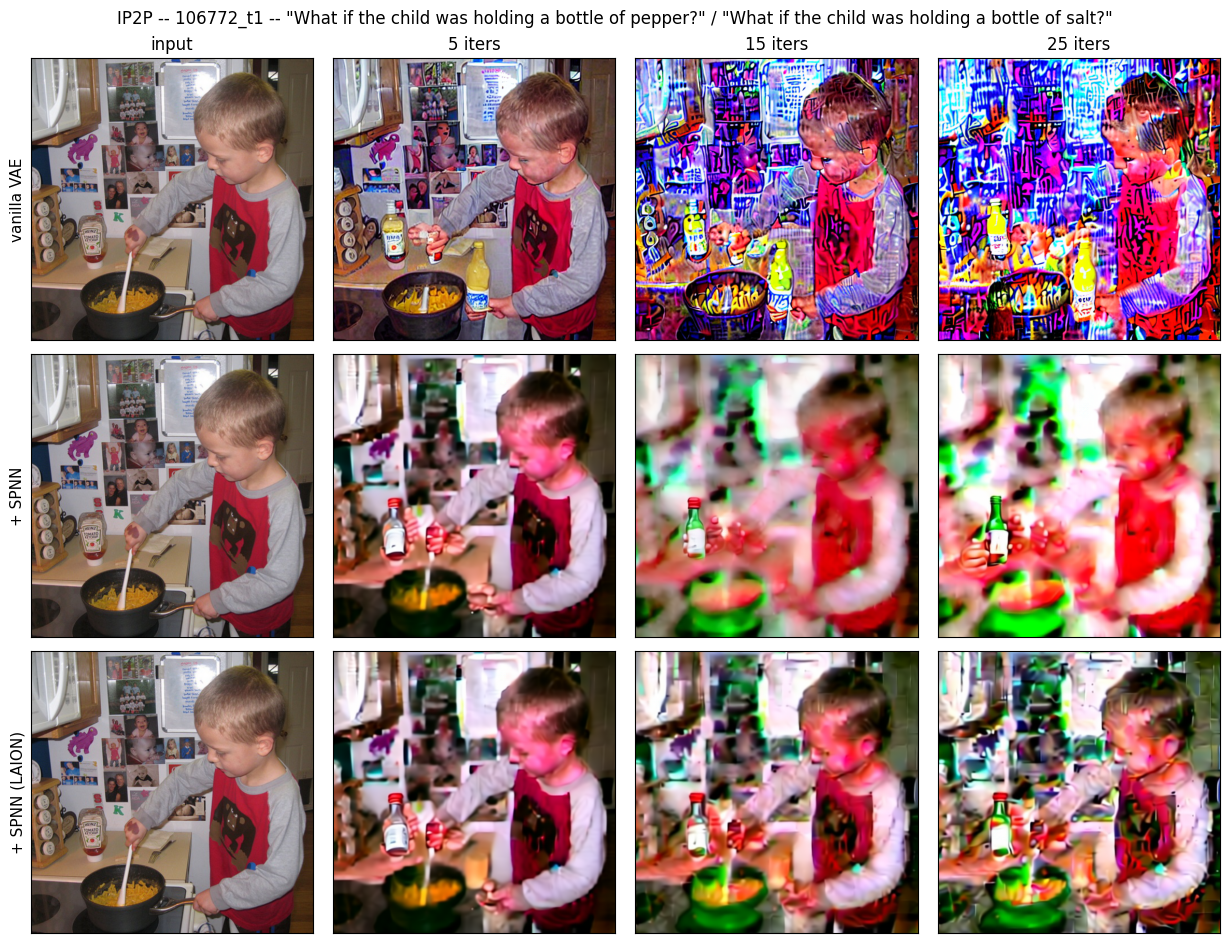

In [44]:
import matplotlib.pyplot as plt


def qualitative(sid=None, editor="IP2P", save=TAB_DIR / "qualitative.png"):
    s = next((x for x in SAMPLES if x["sid"] == sid), SAMPLES[0])
    cols = ["input"] + [f"{n} iters" for n in SAVE_AT]
    fig, ax = plt.subplots(len(CODECS), len(cols), figsize=(3.1 * len(cols), 3.2 * len(CODECS)))
    ax = np.atleast_2d(ax)
    for i, c in enumerate(CODECS):
        ax[i, 0].imshow(load_rgb(s["src"]))
        ax[i, 0].set_ylabel({"vanilla": "vanilla VAE"}.get(c, CODEC_LABEL.get(c, c).strip()),
                            fontsize=11)
        for j, n in enumerate(SAVE_AT, 1):
            p = arm_dir(editor, c, n) / f"{s['sid']}.png"
            if p.exists():
                ax[i, j].imshow(load_rgb(p))
            else:
                ax[i, j].text(0.5, 0.5, "not run", ha="center", va="center")
        for j, t in enumerate(cols):
            ax[i, j].set_xticks([]); ax[i, j].set_yticks([])
            if i == 0:
                ax[i, j].set_title(t, fontsize=12)
    fig.suptitle(f"{editor} -- {s['sid']} -- \"{s['instruction']}\" / \"{s['reverse_instruction']}\"",
                 fontsize=12)
    fig.tight_layout()
    fig.savefig(save, dpi=130, bbox_inches="tight")
    return fig


qualitative(editor="IP2P");

## 10. Appendix &mdash; iterative encode/decode only (the Table 2 setting)

No diffusion model in the loop: encode and decode the 179 source images 25 times and score
against `x_0`. This is Sec. 5.1's ablation setting, it takes minutes rather than GPU-days, and
it isolates the codec from every confound in the editing pipelines.

Run it for both chains (`uint8=True` matches the protocol Table 1 uses; `uint8=False` is the
paper's own ablation setting, where nothing is written to a file between iterations). For this
codec the two disagree completely &mdash; see Section 4b and the notes in Section 12.

In [45]:
@torch.no_grad()
def encode_decode_table(iters=SAVE_AT, uint8=None):
    uint8 = KEEP_UINT8 if uint8 is None else uint8
    ed_dir = OUT_ROOT / "encdec" / ("uint8" if uint8 else "float")
    rows = []
    for c in CODECS:
        vae = build_codec(c)
        for n in iters:
            d = ed_dir / c / f"iter{n}"
            d.mkdir(parents=True, exist_ok=True)
            pairs, per_mse, per_psnr, per_ssim = [], [], [], []
            for s in SAMPLES:
                p = d / f"{s['sid']}.png"
                x0 = load_rgb(s["src"])
                out = load_rgb(p) if p.exists() else _roundtrip(vae, x0, n, uint8=uint8)
                if not p.exists():
                    to_pil(out).save(p)
                    out = load_rgb(p)
                pairs.append((out, x0))
                per_mse.append(mse(out, x0)); per_psnr.append(psnr(out, x0)); per_ssim.append(ssim(out, x0))
            rows.append(dict(codec=c, chain="uint8" if uint8 else "float", iters=n,
                             MSE=np.mean(per_mse), PSNR=np.mean(per_psnr), SSIM=np.mean(per_ssim),
                             LPIPS=float(np.mean(lpips_batch(pairs))),
                             FID=fid(d, REF_DIR / "source")))
            print(f"  encdec {c} @ {n}: {rows[-1]}", flush=True)
        del vae
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    t = pd.DataFrame(rows)
    t.to_csv(TAB_DIR / f"table2_encdec_{'uint8' if uint8 else 'float'}.csv", index=False)
    return t.set_index(["codec", "chain", "iters"])[list(METRICS)].round(4)


# encode_decode_table(uint8=False)   # paper's ablation setting
# encode_decode_table(uint8=True)    # the protocol Table 1 runs

## 11. Running it on the cluster

One SLURM array task per `(editor, codec)` arm, ten tasks. Each task re-executes *this* notebook
with `ARM_EDITOR` / `ARM_CODEC` set, so the rollout code has exactly one definition; the analysis
cells notice the other nine arms are missing, print what they skipped, and move on. When all ten
tasks are done, open the notebook interactively once with no `ARM_*` set and re-run from Section 7
to get the table.

Order of operations:

1. Nothing to prefetch: every checkpoint and both metric backbones are already in `~/.cache`
   (see Section 2b), so `HF_HUB_OFFLINE=1` below is safe as written.
2. `REED_SMOKE=1` for a 4-image / 5-iteration / 10-step plumbing check first &mdash; it writes to a
   separate `_smoke` output tree and takes a few minutes.
3. Then submit the array below.

Budget: ~4.5k pipeline calls per arm. IP2P and MagicBrush run 100 sampler steps per call, DiffEdit
runs three passes per call, so expect roughly 6-15 h per arm on an A100. `--time` is set to 24 h and
every arm resumes, so a timeout just costs one requeue.

In [46]:
NB_PATH  = Path(os.environ.get("REED_NB", str(PROJECT / "reed_table1_spnn.ipynb")))
LOG_DIR  = OUT_ROOT / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
SBATCH   = PROJECT / "run_reed_table1_spnn.sbatch"

arm_list = " ".join(f"{e}:{c}" for e in EDITORS for c in CODECS)

SBATCH.write_text(f"""#!/bin/bash
#SBATCH --job-name=reed_t1
#SBATCH --array=0-{len(EDITORS) * len(CODECS) - 1}%{ARRAY_CONCURRENCY}
#SBATCH --gres=gpu:1
#SBATCH --cpus-per-task=8
#SBATCH --mem=64G
#SBATCH --time=24:00:00
#SBATCH --output={LOG_DIR}/reed_t1_%A_%a.out
set -euo pipefail

ARMS=({arm_list})
ARM="${{ARMS[$SLURM_ARRAY_TASK_ID]}}"
export ARM_EDITOR="${{ARM%%:*}}"
export ARM_CODEC="${{ARM##*:}}"

export REED_PROJECT="{PROJECT}"
export REED_OUT="{BASE_OUT}"
export REED_IDS="{','.join(ONLY_IDS)}"
export REED_SUBSET="{SUBSET_N or 0}"
export REED_SUBSET_SEED="{SUBSET_SEED}"
export HF_HUB_OFFLINE=1                 # everything needed is already in ~/.cache
export TOKENIZERS_PARALLELISM=false

echo "arm=$ARM_EDITOR/$ARM_CODEC host=$(hostname)"
python3 -m jupyter nbconvert --to notebook --execute \\
        --ExecutePreprocessor.timeout=-1 \\
        --output-dir "{LOG_DIR}" \\
        --output "executed_${{ARM_EDITOR}}_${{ARM_CODEC}}.ipynb" \\
        "{NB_PATH}"
""")
SBATCH.chmod(0o755)
print(SBATCH.read_text())

#!/bin/bash
#SBATCH --job-name=reed_t1
#SBATCH --array=0-14%4
#SBATCH --gres=gpu:1
#SBATCH --cpus-per-task=8
#SBATCH --mem=64G
#SBATCH --time=24:00:00
#SBATCH --output=/home/ron.libman/iclr0409/reed_table1_spnn_out_ids106772/logs/reed_t1_%A_%a.out
set -euo pipefail

ARMS=(IP2P:vanilla IP2P:spnn IP2P:spnn_laion MagicBrush:vanilla MagicBrush:spnn MagicBrush:spnn_laion DiffEdit:vanilla DiffEdit:spnn DiffEdit:spnn_laion PbE:vanilla PbE:spnn PbE:spnn_laion SDInpaint:vanilla SDInpaint:spnn SDInpaint:spnn_laion)
ARM="${ARMS[$SLURM_ARRAY_TASK_ID]}"
export ARM_EDITOR="${ARM%%:*}"
export ARM_CODEC="${ARM##*:}"

export REED_PROJECT="/home/ron.libman/iclr0409"
export REED_OUT="/home/ron.libman/iclr0409/reed_table1_spnn_out"
export REED_IDS="106772"
export REED_SUBSET="0"
export REED_SUBSET_SEED="0"
export HF_HUB_OFFLINE=1                 # everything needed is already in ~/.cache
export TOKENIZERS_PARALLELISM=false

echo "arm=$ARM_EDITOR/$ARM_CODEC host=$(hostname)"
python3 -m jupyter nbconvert --

In [47]:
print(f"smoke test:   REED_SMOKE=1 ARM_EDITOR=IP2P ARM_CODEC=spnn python3 -m jupyter nbconvert "
      f"--to notebook --execute --ExecutePreprocessor.timeout=-1 --output-dir {LOG_DIR} "
      f"--output smoke.ipynb {NB_PATH}")
print(f"full grid:    sbatch {SBATCH}")
print(f"progress:     tail -f {LOG_DIR}/reed_t1_*.out")

smoke test:   REED_SMOKE=1 ARM_EDITOR=IP2P ARM_CODEC=spnn python3 -m jupyter nbconvert --to notebook --execute --ExecutePreprocessor.timeout=-1 --output-dir /home/ron.libman/iclr0409/reed_table1_spnn_out_ids106772/logs --output smoke.ipynb /home/ron.libman/iclr0409/reed_table1_spnn.ipynb
full grid:    sbatch /home/ron.libman/iclr0409/run_reed_table1_spnn.sbatch
progress:     tail -f /home/ron.libman/iclr0409/reed_table1_spnn_out_ids106772/logs/reed_t1_*.out


## 12. Notes, and where this departs from the paper

**Substitutions (the point of the notebook).**

* The base rows use the SD 1.5 VAE (`stable-diffusion-v1-5/stable-diffusion-v1-5`, subfolder
  `vae`) as the codec for all five models. They all share the KL-f8 / 4-channel / `0.18215`
  latent space, which is what makes a single codec swappable across all of them &mdash; the same
  property REED-VAE relies on.
* The `+ SPNN` rows use `ckpt_last.pt` with `spnn_model.SPNNAutoencoder512`, in place of REED-VAE.
  That checkpoint was distilled against exactly this VAE, so the baseline codec and the SPNN
  codec's training target are the same object; Section 4b reports the residual gap, which is
  SPNN's approximation error alone.
* SD 2.1 was the original intent for the base rows. Every `stabilityai/*` repo returns 401
  anonymously and 404 with the account's cached token, so no SD2 checkpoint is reachable from this
  machine. `VANILLA_VAE_ID` (and `MODEL_IDS["DiffEdit"]`, `MODEL_IDS["SDInpaint"]`) are the only
  lines that would change if that access comes back.
* `SPNN_WEIGHTS = "ema"` uses the EMA shadow. Set it to `"model"` for the raw weights.

**Choices the paper does not pin down** (all in `CONFIG`):

* `REFERENCE = "alternating"` &mdash; metrics at 5/15/25 are scored against `x_t`, since an odd
  number of alternating inverse edits should land on the target state. `"target"` and `"source"`
  are the other two readings.
* Sampler settings are each pipeline's documented defaults (`EDIT_KWARGS`); the paper reports none.
* `DiffEdit` is not a checkpoint of its own &mdash; it is a recipe over any SD text-to-image model
  plus a DDIM/DDIM-inverse scheduler pair, so it runs on SD1.5 here, at the dataset's native 512x512.
* `SDInpaint` uses `runwayml/stable-diffusion-inpainting`, the 9-channel SD1.5 inpainting UNet.

**The one real data deviation.** Paint-by-Example's `x1r` in the paper is ImagenHub's subject
reference image, which is not in the 179-sample mask-guided split shipped in `REED-VAE-data/`. We
derive it the same way the paper derives `x2r`: the mask's tight bounding box cropped from `x_t`
(for `x1r`) and from `x_s` (for `x2r`). The alternation the paper describes is intact; only where
`x1r` comes from differs.

**`KEEP_UINT8` is the load-bearing switch for this codec, not a detail.**

Measured on 8 images, iterative encode/decode, PSNR at 1 / 5 / 15 / 25 (fp32 and fp16 agree to
within 0.05 dB throughout, so precision is not a factor):

| codec | chain | 1 | 5 | 15 | 25 |
| --- | --- | --- | --- | --- | --- |
| vanilla | float | 30.26 | 23.13 | 14.00 | 10.00 |
| vanilla | uint8 | 30.26 | 23.19 | 13.68 | 9.76 |
| SPNN | float | 32.36 | 32.36 | 32.36 | 32.36 |
| SPNN | uint8 | 32.37 | 24.74 | 20.47 | 18.56 |

`decode(encode(.))` is a **fixed point** for the SPNN codec: one pass lands the image on the
codec's own reconstruction manifold, and every further pass is a no-op, so the float chain is
flat to two decimals out to 25 iterations. This is a stronger invariance than REED-VAE's, which
still decays (Table 2 of the paper: 28.86 -> 22.79 -> 20.16 dB). It is also fragile in a specific
way: rounding to 8 bits kicks the image off that manifold, and the error then compounds. The
vanilla VAE has no fixed point to lose, so quantisation costs it almost nothing on top of its own
reconstruction error.

`KEEP_UINT8 = True` is faithful to the paper's premise &mdash; multi-method editing means a user
saving a file between operations &mdash; and it is what Table 1 runs. But `output_type="np"` keeps
the pipelines in float end to end, so `KEEP_UINT8 = False` is equally runnable, and for this codec
it is a different experiment rather than a rounding detail. Run both; the pair separates the
codec's reconstruction quality from its quantisation robustness, and a single table cannot.

**Things that are deliberately *not* free parameters.**

* Both codecs see the same seeds, the same prompts, the same masks and the same sampler settings.
  A Table 1 block differs in the codec and nothing else.
* Nothing in the table is copied from the paper. `PAPER_TABLE1` in Section 8b exists only so the
  two can be looked at side by side, and it is never read by `build_table1`.